# 7주차: 확률 기초와 MLE — 교실 실습
> 인공지능수학 | 교실 실습용 노트북  
> 구성: 손문제 (35분) → 🐛 버그 잡기 팀활동 (20분) → 코딩 실습 (20분)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, log

---
## Part 1. 손문제 (35분)

### 문제 1 — 조건부 확률과 독립성 판단

학생 200명에 대한 조사 결과입니다.

| | 수학 좋아함 ($M$) | 수학 안 좋아함 ($M^c$) | 합계 |
|---|:---:|:---:|:---:|
| AI 전공 ($A$) | 80 | 40 | 120 |
| 비AI 전공 ($A^c$) | 20 | 60 | 80 |
| 합계 | 100 | 100 | 200 |

**(1)** $P(M)$, $P(A)$, $P(M \cap A)$를 구하시오.

**(2)** $P(M \mid A)$와 $P(M \mid A^c)$를 구하시오.

**(3)** 사건 $M$과 $A$는 독립인가? 판단 기준을 명확히 쓰시오.

---
*(풀이 공간)*







### 문제 2 — 이항분포와 우도 계산

새로운 약이 특정 증상에 효과가 있을 확률이 $p$라고 합시다.  
임상 시험에서 환자 8명에게 투여했더니 5명에게 효과가 있었습니다.

**(1)** 이항분포 공식을 사용하여 $p = 0.5$일 때의 우도 $L(0.5 \mid k=5, n=8)$를 계산하시오.  
  단, $\binom{8}{5} = 56$임을 이용하시오.

**(2)** $p = 0.625 = 5/8$일 때의 우도 $L(0.625 \mid k=5, n=8)$를 계산하시오.

**(3)** 두 우도를 비교하여 어느 $p$가 더 그럴듯한지 설명하시오.

**(4)** 이항분포 MLE 공식 $\hat{p} = k/n$을 적용하면 얼마인가? (1), (2) 결과와 일치하는가?

---
*(풀이 공간)*







### 문제 3 — log-likelihood와 MLE 유도

동전을 $n$번 던져 $k$번 앞면이 나왔을 때의 log-likelihood는:

$$\ell(p) = k \log p + (n-k) \log(1-p)$$

**(1)** $\dfrac{d\ell}{dp}$를 구하시오.

**(2)** $\dfrac{d\ell}{dp} = 0$으로 놓고 $\hat{p}$를 구하시오.

**(3)** $\dfrac{d^2\ell}{dp^2}$을 구하고, 구한 $\hat{p}$에서 이 값의 부호를 확인하시오.  
  왜 이것이 최댓값임을 보장하는가?

**(4)** $n = 50, k = 30$일 때 $\hat{p}$를 구하시오.

---
*(풀이 공간)*







### 문제 4 — 직관 질문: 확률 vs 우도

다음 두 질문을 읽고, 각각이 **확률**을 묻는 것인지 **우도**를 묻는 것인지 판단하고 이유를 쓰시오.

**(A)** "앞면 확률이 $0.7$인 동전을 10번 던졌을 때, 앞면이 정확히 7번 나올 가능성은?"

**(B)** "동전을 10번 던졌더니 앞면이 7번 나왔다. 이 동전의 앞면 확률이 $0.7$이라는 게 얼마나 그럴듯한가?"

**(C)** 두 질문의 수식은 **형태가 같지만** 관점이 다릅니다. 어떻게 다른지 한 문장으로 설명하시오.

---
*(풀이 공간)*







---
## Part 2. 🐛 버그 잡기 팀활동 (20분)

> 영상에서 본 버그입니다. 팀원들과 논의하여 원인을 찾고 수정하세요.

### 버그 설명

아래 코드는 $n=20, k=13$에서 이항분포의 최대우도를 수치적으로 찾으려 합니다.  
실행하면 `p_hat ≈ 0.99`로 발산합니다. 이론값은 $13/20 = 0.65$여야 합니다.

**버그 유형: 연산자 오류 (+ vs *)**

추정된 p_hat = 0.650
이론값 k/n  = 0.650


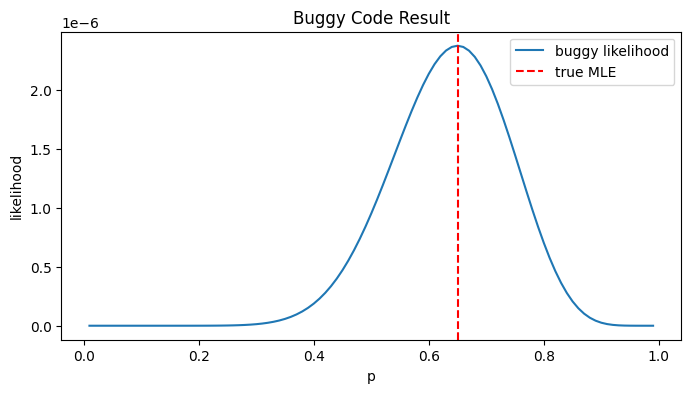

In [8]:
# 🐛 Buggy code
n, k = 20, 13
p_vals = np.linspace(0.01, 0.99, 99)

likelihood = p_vals**k + (1 - p_vals)**(n - k)   # Bug is here!

p_hat = p_vals[np.argmax(likelihood)]
print(f"추정된 p_hat = {p_hat:.3f}")
print(f"이론값 k/n  = {k/n:.3f}")

# Visualize to see what's wrong
plt.figure(figsize=(8, 4))
plt.plot(p_vals, likelihood, label='buggy likelihood')
plt.axvline(x=k/n, color='red', linestyle='--', label='true MLE')
plt.xlabel('p')
plt.ylabel('likelihood')
plt.title('Buggy Code Result')
plt.legend()
plt.show()

**팀 토론:**
1. 이항분포의 우도 공식 $L(p) = \binom{n}{k} p^k (1-p)^{n-k}$에서 $p^k$와 $(1-p)^{n-k}$는 어떻게 결합되는가?
2. 코드의 `+` 연산자를 보면 어떤 함수를 계산하고 있는가?
3. 왜 `+` 연산자가 `p_hat → 1` 방향으로 발산시키는가?

수정된 코드를 아래에 작성하세요:

In [ ]:
# ✅ Fixed code (팀이 수정한 버전)
n, k = 20, 13
p_vals = np.linspace(0.01, 0.99, 300)

likelihood = ______   # 올바른 우도 계산으로 수정하세요

p_hat = p_vals[np.argmax(likelihood)]
print(f"수정 후 p_hat = {p_hat:.3f}")
print(f"이론값 k/n   = {k/n:.3f}")

---
## [참고용] 시험범위 제외
## Part 3. 코딩 실습 (20분)

### 실습 1 — 손문제 2번 검증

손문제에서 직접 계산한 $L(0.5)$와 $L(0.625)$ 값을 코드로 검증하세요.

In [5]:
# Verify hand calculations from Problem 2
n, k = 8, 5

def likelihood_binom(p, n, k):
    """Exact binomial likelihood including the combination coefficient."""
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

L_05  = likelihood_binom(0.5, n, k)
L_625 = likelihood_binom(0.625, n, k)

print(f"L(p=0.5)   = {L_05:.6f}")
print(f"L(p=0.625) = {L_625:.6f}")
print(f"손계산과 일치하는가? 직접 비교해보세요.")

L(p=0.5)   = 0.218750
L(p=0.625) = 0.281632
손계산과 일치하는가? 직접 비교해보세요.


### 실습 2 — MLE 추정과 시각화

다음 세 가지 관측값에 대해 각각 이항분포 MLE를 구하고, 우도 곡선을 한 그래프에 시각화하세요.

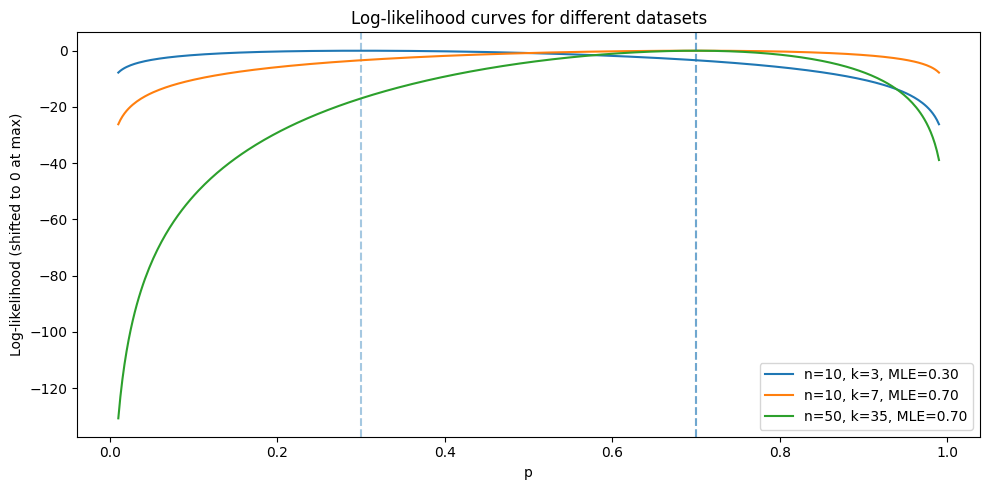


각 데이터셋의 MLE:
  n=10, k=3 → p_hat = 0.300
  n=10, k=7 → p_hat = 0.700
  n=50, k=35 → p_hat = 0.700


In [3]:
# MLE for three different datasets
datasets = [
    (10, 3),    # n=10, k=3
    (10, 7),    # n=10, k=7
    (50, 35),   # n=50, k=35
]

p_vals = np.linspace(0.01, 0.99, 400)

plt.figure(figsize=(10, 5))

for n, k in datasets:
    # Compute log-likelihood (normalized for comparison)
    ll = np.array([k * np.log(p) + (n-k) * np.log(1-p) for p in p_vals])
    ll_norm = (ll - ll.max())  # shift so max = 0

    plt.plot(p_vals, ll_norm, label=f'n={n}, k={k}, MLE={k/n:.2f}')
    plt.axvline(x=k/n, linestyle='--', alpha=0.4)

plt.xlabel('p')
plt.ylabel('Log-likelihood (shifted to 0 at max)')
plt.title('Log-likelihood curves for different datasets')
plt.legend()
plt.tight_layout()
plt.show()

print("\n각 데이터셋의 MLE:")
for n, k in datasets:
    print(f"  n={n}, k={k} → p_hat = {k/n:.3f}")

**관찰:**  
샘플 수($n$)가 커질수록 우도 곡선이 어떻게 변하나요?  
이것이 통계적으로 어떤 의미인지 한 문장으로 쓰세요.

*(관찰 내용 작성 공간)*


### 실습 3 — 조건부 확률 시뮬레이션

손문제 1번의 결과를 시뮬레이션으로 검증하세요.  
200명 학생 데이터를 NumPy 배열로 만들고 $P(M \mid A)$를 계산합니다.

In [4]:
# Simulate the student survey (Problem 1)
np.random.seed(7)

# Create student data: True = AI major, False = non-AI major
# AI majors: 120 students (80 like math, 40 don't)
# Non-AI majors: 80 students (20 like math, 60 don't)

is_AI   = np.array([True]*120  + [False]*80)
likes_M = np.array([True]*80 + [False]*40 + [True]*20 + [False]*60)

# Compute probabilities
P_M   = likes_M.mean()
P_A   = is_AI.mean()
P_M_and_A = (likes_M & is_AI).mean()

# P(M|A)
P_M_given_A = P_M_and_A / P_A

# P(M|A^c)
P_A_c = (~is_AI).mean()
P_M_given_Ac = (likes_M & ~is_AI).mean() / P_A_c

print(f"P(M)      = {P_M:.3f}")
print(f"P(A)      = {P_A:.3f}")
print(f"P(M∩A)    = {P_M_and_A:.3f}")
print(f"P(M|A)    = {P_M_given_A:.3f}")
print(f"P(M|A^c)  = {P_M_given_Ac:.3f}")
print()

# Independence check
print("독립성 확인:")
print(f"  P(M) * P(A)   = {P_M * P_A:.3f}")
print(f"  P(M ∩ A)      = {P_M_and_A:.3f}")
print(f"  독립인가? {np.isclose(P_M * P_A, P_M_and_A, atol=0.01)}")

P(M)      = 0.500
P(A)      = 0.600
P(M∩A)    = 0.400
P(M|A)    = 0.667
P(M|A^c)  = 0.250

독립성 확인:
  P(M) * P(A)   = 0.300
  P(M ∩ A)      = 0.400
  독립인가? False
